### Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Unzip Test Dataset

In [2]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/carla_dataset/test.zip', 'r') as zip_ref:
    zip_ref.extractall('test')

print("Done")

Done


### Import Libraries

In [58]:

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset

### Load Test Labels

In [4]:
labels_df_test = pd.read_csv(
    "test/test/labels.csv"
)

labels_df_test.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


### DrivingDataset Class Definition

In [5]:
class DrivingDataset(Dataset):

    def __init__(self,
                 image_folder,
                 labels_df,
                 target_column,
                 transform=None):

        self.image_folder = image_folder
        self.labels_df = labels_df
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):

        frame = self.labels_df.iloc[idx]["frame"]

        image_path = f"{self.image_folder}/{frame}.png"

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.labels_df.iloc[idx][self.target_column]

        label = float(label)

        return image, label


### Define 64x64 Image Transformations

In [6]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

### Set Device (CPU/GPU)

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


### TrafficLightClassifier Class Definition (64x64 input)

In [8]:
class TrafficLightClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,16,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64*8*8,128),
            nn.ReLU(),

            nn.Linear(128,1)
        )

    def forward(self,x):
        return self.model(x)


### Define 224x224 Image Transformations

In [9]:
transform_224 = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

### TrafficLightClassifier224 Class Definition (224x224 input)

In [10]:
class TrafficLightClassifier224(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,16,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64*28*28,128),
            nn.ReLU(),

            nn.Linear(128,1)
        )

    def forward(self,x):
        return self.model(x)

### Load Traffic Light Model

In [12]:
traffic_light_model_224 = TrafficLightClassifier224().to(device)

traffic_light_model_224.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/carla_dataset/traffic_light_model.pth",
        map_location=device
    )
)

traffic_light_model_224.eval()

print("Traffic Light model loaded")

Traffic Light model loaded


### Create Traffic Light Test Dataset (original)

In [13]:
traffic_light_test_dataset = DrivingDataset(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_traffic_light",
    transform=transform_224
)

print(len(traffic_light_test_dataset))

3600


### Verify Test Directory Contents

In [14]:

import os

print(os.getcwd())
print(os.listdir("test"))

/content
['test']


### Verify Test Subdirectory Contents

In [15]:
print(os.listdir("test/test"))

['imu.feather', 'rgb-front', 'actions.feather', 'sim.log', 'carla.log', 'weather.feather', 'collisions.feather', 'labels.csv', '.hydra', 'labels.feather', 'gnss.feather', 'segmentation-front']


### List Image Files in `rgb-front`

In [16]:
import os

image_files = os.listdir("test/test/rgb-front")

print("Number of images:", len(image_files))
print("First 10 images:")
print(image_files[:10])

Number of images: 3600
First 10 images:
['021130.jpg', '008190.jpg', '026490.jpg', '027610.jpg', '009480.jpg', '020970.jpg', '022400.jpg', '023950.jpg', '023200.jpg', '032650.jpg']


### Inspect `labels_df_test` Frame Column

In [17]:
print(labels_df_test["frame"].head(10))

0     0
1    10
2    20
3    30
4    40
5    50
6    60
7    70
8    80
9    90
Name: frame, dtype: int64


### Check for Specific Image Files (e.g., '000000')

In [18]:
matches = [f for f in image_files if f.startswith("000000")]

print(matches[:20])

['000000.jpg']


### Inspect First 50 Image Filenames

In [19]:
print(image_files[0:50])

['021130.jpg', '008190.jpg', '026490.jpg', '027610.jpg', '009480.jpg', '020970.jpg', '022400.jpg', '023950.jpg', '023200.jpg', '032650.jpg', '014470.jpg', '016270.jpg', '025830.jpg', '023530.jpg', '000540.jpg', '032530.jpg', '020460.jpg', '029650.jpg', '000220.jpg', '023550.jpg', '018640.jpg', '013290.jpg', '005900.jpg', '017970.jpg', '019070.jpg', '005070.jpg', '000230.jpg', '011760.jpg', '030240.jpg', '007190.jpg', '009520.jpg', '029230.jpg', '031600.jpg', '035300.jpg', '009220.jpg', '004730.jpg', '020990.jpg', '014500.jpg', '032880.jpg', '009190.jpg', '021980.jpg', '018200.jpg', '035780.jpg', '030270.jpg', '031670.jpg', '013250.jpg', '003820.jpg', '029960.jpg', '007320.jpg', '003970.jpg']


### DrivingDataset224Fixed Class Definition

In [20]:
from PIL import Image
from torch.utils.data import Dataset

class DrivingDataset224Fixed(Dataset):

    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_folder = image_folder
        self.labels_df = labels_df
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):

        frame = self.labels_df.iloc[idx]["frame"]

        image_name = f"{int(frame):06d}.jpg"

        image_path = f"{self.image_folder}/{image_name}"

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = float(
            self.labels_df.iloc[idx][self.target_column]
        )

        return image, label

### Create Fixed Traffic Light Test Dataset

In [21]:
traffic_light_test_dataset_fixed = DrivingDataset224Fixed(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_traffic_light",
    transform=transform_224
)

print(len(traffic_light_test_dataset_fixed))

3600


### Generate and Visualize Traffic Light Saliency Map (Example 1)

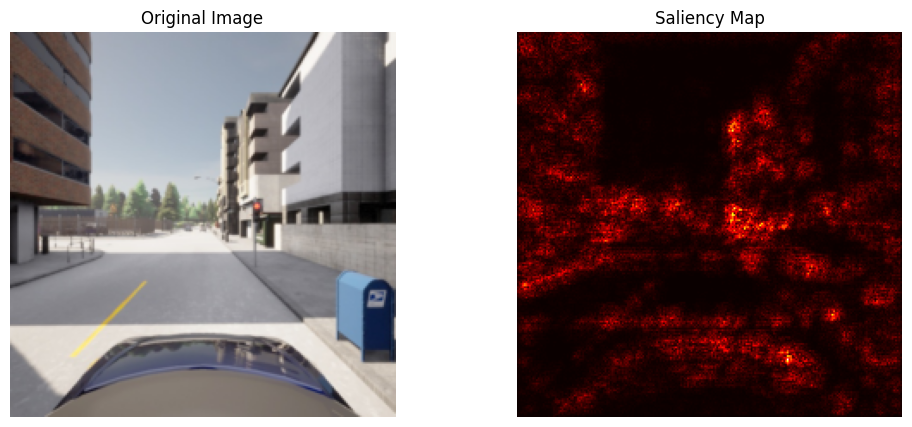

In [22]:
image, label = traffic_light_test_dataset_fixed[1]

input_image = image.unsqueeze(0).to(device)

input_image.requires_grad_()

output = traffic_light_model_224(input_image)

output.backward()

saliency = input_image.grad.abs().max(dim=1)[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(saliency.squeeze().cpu(), cmap="hot")
plt.title("Saliency Map")
plt.axis("off")

plt.show()

### Find Correctly Classified Traffic Light Images

In [23]:
correct_indices = []

for i in range(len(traffic_light_test_dataset_fixed)):

    image, label = traffic_light_test_dataset_fixed[i]

    with torch.no_grad():

        pred = torch.sigmoid(
            traffic_light_model_224(
                image.unsqueeze(0).to(device)
            )
        ).item()

    prediction = 1 if pred > 0.5 else 0

    if prediction == int(label):
        correct_indices.append(i)

    if len(correct_indices) == 5:
        break

print(correct_indices)

[0, 1, 2, 3, 4]


### Visualize Saliency Maps for Correct Traffic Light Predictions

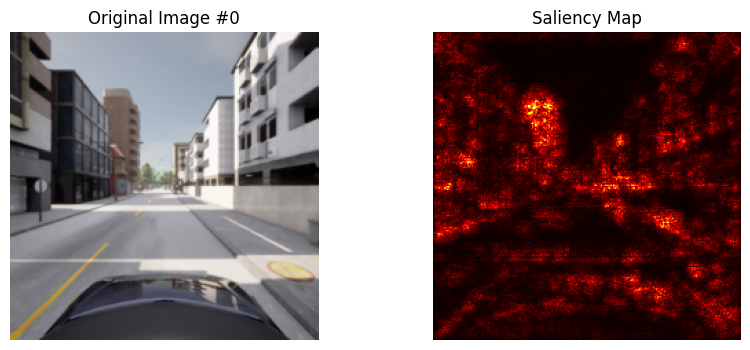

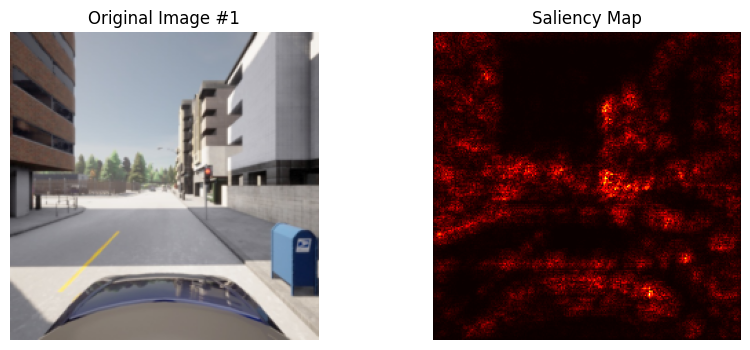

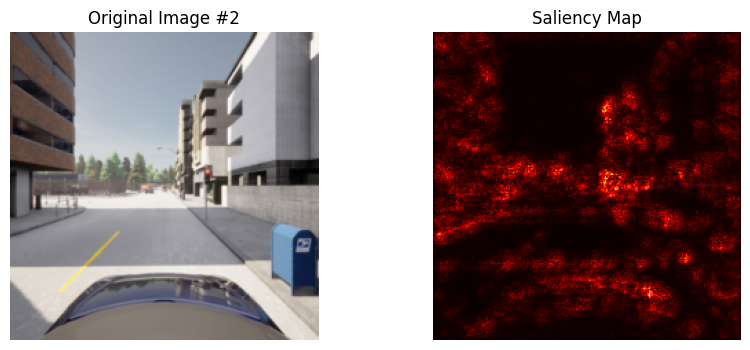

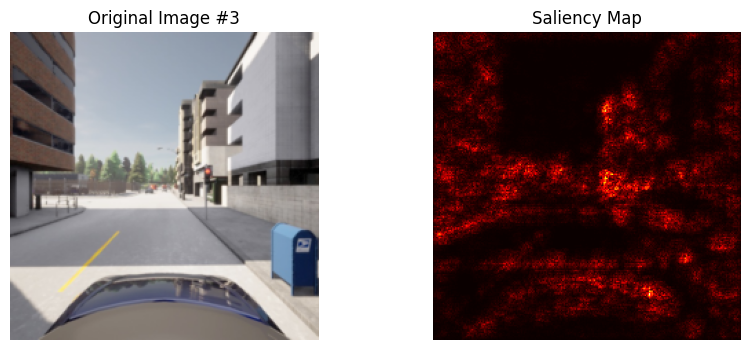

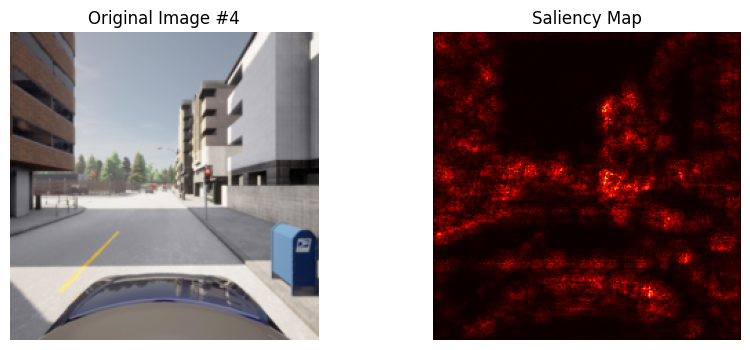

In [24]:
for idx in [0, 1, 2, 3, 4]:

    image, label = traffic_light_test_dataset_fixed[idx]

    input_image = image.unsqueeze(0).to(device)
    input_image.requires_grad_(True)

    output = traffic_light_model_224(input_image)

    traffic_light_model_224.zero_grad()
    output.backward()

    saliency = input_image.grad.abs().max(dim=1)[0]

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Original Image #{idx}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(saliency.squeeze().cpu(), cmap="hot")
    plt.title("Saliency Map")
    plt.axis("off")

    plt.show()

### List .pth Model Files in Google Drive

In [25]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/ML_Safety"):
    for file in files:
        if file.endswith(".pth"):
            print(file)

### Inspect Columns of `labels_df_test`

In [26]:
print(labels_df_test.columns)

Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


### Pedestrian Classifier Definition and Model Loading

In [28]:
class PedestrianClassifier224(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64*28*28,128),
            nn.ReLU(),

            nn.Linear(128,1)
        )

    def forward(self,x):
        return self.model(x)


pedestrian_model_224 = PedestrianClassifier224().to(device)

pedestrian_model_224.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/carla_dataset/pedestrian_model.pth",
        map_location=device
    )
)

pedestrian_model_224.eval()

print("Pedestrian model loaded")

Pedestrian model loaded


### Find Correctly Classified Pedestrian Images

In [29]:
pedestrian_test_dataset_fixed = DrivingDataset224Fixed(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_pedestrian",
    transform=transform_224
)

correct_indices = []

for i in range(len(pedestrian_test_dataset_fixed)):

    image, label = pedestrian_test_dataset_fixed[i]

    with torch.no_grad():

        pred = torch.sigmoid(
            pedestrian_model_224(
                image.unsqueeze(0).to(device)
            )
        ).item()

    prediction = 1 if pred > 0.5 else 0

    if prediction == int(label):
        correct_indices.append(i)

    if len(correct_indices) == 5:
        break

print(correct_indices)

[0, 1, 2, 3, 4]


### Generate and Visualize Pedestrian Saliency Map (Example 1)

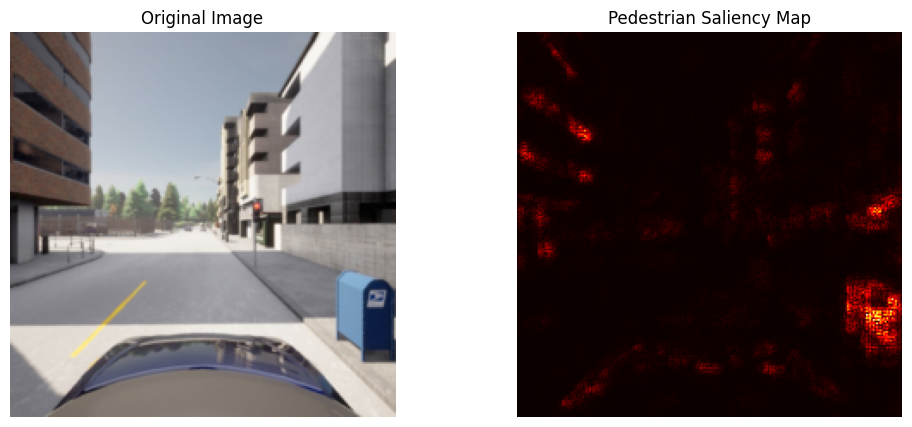

In [30]:
image, label = pedestrian_test_dataset_fixed[1]

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad_(True)

output = pedestrian_model_224(input_image)

pedestrian_model_224.zero_grad()
output.backward()

saliency = input_image.grad.abs().max(dim=1)[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(saliency.squeeze().cpu(), cmap="hot")
plt.title("Pedestrian Saliency Map")
plt.axis("off")

plt.show()

### Vehicle Classifier Definition and Model Loading

In [32]:
class VehicleClassifier224(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),

            nn.Linear(64*28*28,128),
            nn.ReLU(),

            nn.Linear(128,1)
        )

    def forward(self,x):
        return self.model(x)


vehicle_model_224 = VehicleClassifier224().to(device)

vehicle_model_224.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/carla_dataset/vehicle_model.pth",
        map_location=device
    )
)

vehicle_model_224.eval()

print("Vehicle model loaded")

Vehicle model loaded


### Find Correctly Classified Vehicle Images

In [33]:
vehicle_test_dataset_fixed = DrivingDataset224Fixed(
    image_folder="test/test/rgb-front",
    labels_df=labels_df_test,
    target_column="has_vehicle",
    transform=transform_224
)

correct_indices = []

for i in range(len(vehicle_test_dataset_fixed)):

    image, label = vehicle_test_dataset_fixed[i]

    with torch.no_grad():

        pred = torch.sigmoid(
            vehicle_model_224(
                image.unsqueeze(0).to(device)
            )
        ).item()

    prediction = 1 if pred > 0.5 else 0

    if prediction == int(label):
        correct_indices.append(i)

    if len(correct_indices) == 5:
        break

print(correct_indices)

[1, 2, 3, 4, 5]


### Generate and Visualize Vehicle Saliency Map (Example 1)

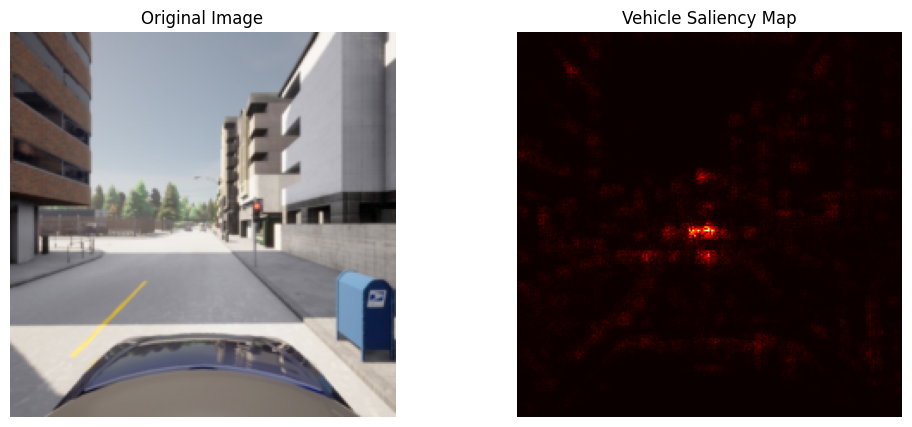

In [34]:
image, label = vehicle_test_dataset_fixed[1]

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad_(True)

output = vehicle_model_224(input_image)

vehicle_model_224.zero_grad()
output.backward()

saliency = input_image.grad.abs().max(dim=1)[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(saliency.squeeze().cpu(), cmap="hot")
plt.title("Vehicle Saliency Map")
plt.axis("off")

plt.show()

### Find Misclassified Traffic Light Images

In [35]:
wrong_indices = []

for i in range(len(traffic_light_test_dataset_fixed)):
    image, label = traffic_light_test_dataset_fixed[i]

    with torch.no_grad():
        pred = torch.sigmoid(
            traffic_light_model_224(
                image.unsqueeze(0).to(device)
            )
        ).item()

    prediction = 1 if pred > 0.5 else 0

    if prediction != int(label):
        wrong_indices.append(i)

    if len(wrong_indices) == 3:
        break

print(wrong_indices)

[13, 16, 29]


### Visualize Saliency Maps for Misclassified Traffic Light Images

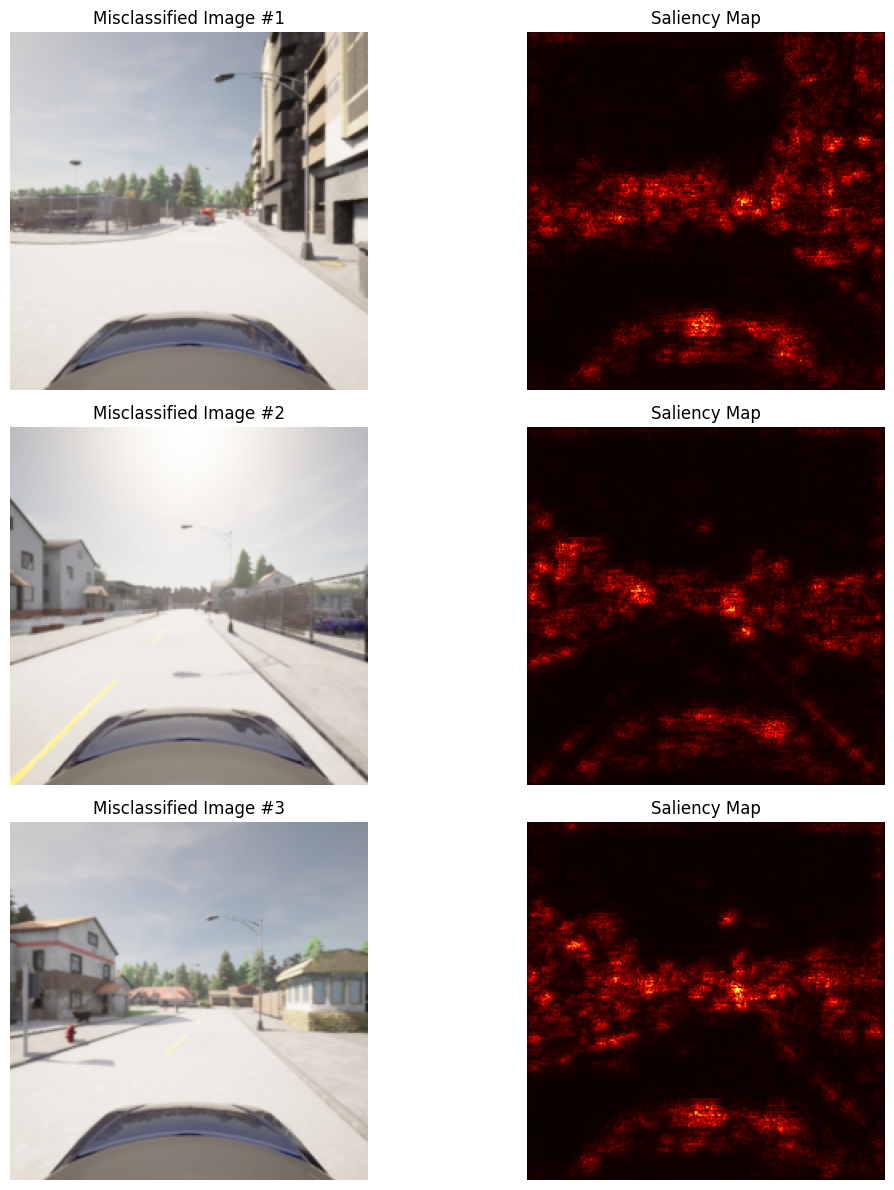

In [36]:
plt.figure(figsize=(12,12))

for plot_idx, idx in enumerate(wrong_indices):

    image, label = traffic_light_test_dataset_fixed[idx]

    input_image = image.unsqueeze(0).to(device)
    input_image.requires_grad_()

    output = traffic_light_model_224(input_image)

    output.backward()

    saliency = input_image.grad.abs().max(dim=1)[0]

    plt.subplot(3,2,2*plot_idx+1)
    plt.imshow(image.permute(1,2,0))
    plt.title(f"Misclassified Image #{plot_idx+1}")
    plt.axis("off")

    plt.subplot(3,2,2*plot_idx+2)
    plt.imshow(saliency.squeeze().cpu(), cmap="hot")
    plt.title("Saliency Map")
    plt.axis("off")

plt.tight_layout()
plt.show()

### List Contents of Carla Dataset Folder

In [38]:
import os

print(os.listdir("/content/drive/MyDrive/carla_dataset"))

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


### Unzip Fog and Night Test Datasets

In [41]:
!unzip -q "/content/drive/MyDrive/carla_dataset/test-fog.zip" -d "/content/test-fog"
!unzip -q "/content/drive/MyDrive/carla_dataset/test-night.zip" -d "/content/test-night"

replace /content/test-fog/test-fog/.hydra/config.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/.hydra/hydra.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/.hydra/overrides.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/actions.feather? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/carla.log? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/collisions.feather? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/gnss.feather? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/imu.feather? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/labels.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/labels.feather? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/test-fog/test-fog/rgb-front/000000.jpg? [y]es, [n]o, [A]ll, [N]one, 

### Verify Unzipped Fog and Night Directories

In [42]:

import os

print("FOG:")
print(os.listdir("/content/test-fog"))

print("\nNIGHT:")
print(os.listdir("/content/test-night"))

FOG:
['test-fog']

NIGHT:
['test-night']


### List Contents of `test-fog` Subdirectory

In [43]:
import os

print(os.listdir("/content/test-fog/test-fog"))

['imu.feather', 'rgb-front', 'actions.feather', 'sim.log', 'carla.log', 'weather.feather', 'collisions.feather', 'labels.csv', '.hydra', 'labels.feather', 'gnss.feather', 'segmentation-front']


### List Contents of `test-night` Subdirectory

In [44]:
print(os.listdir("/content/test-night/test-night"))

['imu.feather', 'rgb-front', 'actions.feather', 'sim.log', 'carla.log', 'weather.feather', 'collisions.feather', 'labels.csv', '.hydra', 'labels.feather', 'gnss.feather', 'segmentation-front']


### Load Fog Labels and Inspect Data

In [45]:
labels_df_fog = pd.read_csv("/content/test-fog/test-fog/labels.csv")

print(labels_df_fog.head())
print(len(labels_df_fog))

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         True               298   
3     30               True           False         True               297   
4     40               True           False         True               297   

   px_pedestrian  px_vehicle  
0              0          35  
1              0         116  
2              0         307  
3              0         258  
4              0         249  
3600


### Create Fog Dataset

In [46]:
fog_dataset = DrivingDataset224Fixed(
    image_folder="/content/test-fog/test-fog/rgb-front",
    labels_df=labels_df_fog,
    target_column="has_traffic_light",
    transform=transform_224
)

print(len(fog_dataset))

3600


### Compute Saliency Map for Fog Image

In [47]:
idx = 0

image, label = fog_dataset[idx]

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad_(True)

output = traffic_light_model_224(input_image)

traffic_light_model_224.zero_grad()
output.backward()

saliency = input_image.grad.abs().max(dim=1)[0]

### Visualize Saliency Map for Fog Image

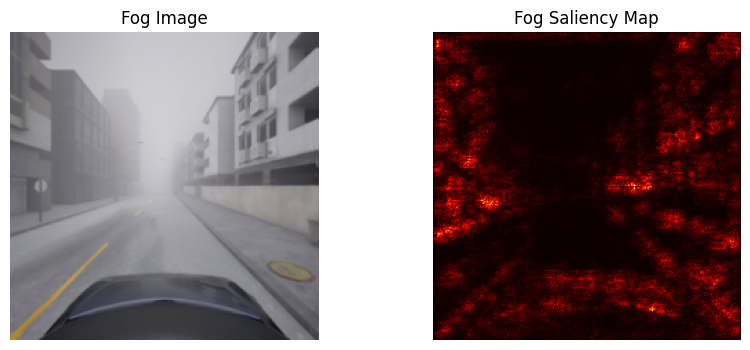

In [48]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Fog Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(saliency.squeeze().cpu(), cmap="hot")
plt.title("Fog Saliency Map")
plt.axis("off")

plt.show()

### Load Night Labels and Create Dataset

### Fog Image Saliency Map

In [49]:
labels_df_night = pd.read_csv("/content/test-night/test-night/labels.csv")

night_dataset = DrivingDataset224Fixed(
    image_folder="/content/test-night/test-night/rgb-front",
    labels_df=labels_df_night,
    target_column="has_traffic_light",
    transform=transform_224
)

### Compute Saliency Map for Night Image

In [50]:
idx = 0

image, label = night_dataset[idx]

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad_(True)

output = traffic_light_model_224(input_image)

traffic_light_model_224.zero_grad()
output.backward()

saliency = input_image.grad.abs().max(dim=1)[0]

### Visualize Saliency Map for Night Image

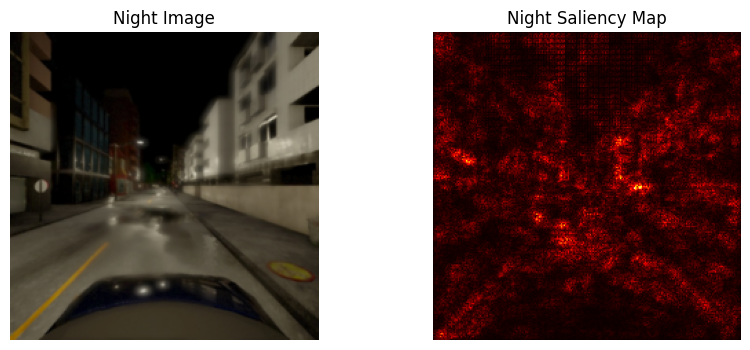

In [51]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Night Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(saliency.squeeze().cpu(), cmap="hot")
plt.title("Night Saliency Map")
plt.axis("off")

plt.show()

### Unzip Town Layout Test Dataset

### Night Image Saliency Map

In [52]:
!unzip -q "/content/drive/MyDrive/carla_dataset/test-town-01.zip" -d "/content/test-town"

y
y


### Verify Unzipped Town Layout Directory

In [53]:

import os
print(os.listdir("/content/test-town"))

['test-town-01']


### List Contents of `test-town-01` Subdirectory

In [54]:

print(os.listdir("/content/test-town/test-town-01"))

['imu.feather', 'rgb-front', 'actions.feather', 'sim.log', 'carla.log', 'weather.feather', 'collisions.feather', 'labels.csv', '.hydra', 'labels.feather', 'gnss.feather', 'segmentation-front']


### Load Town Layout Labels and Create Dataset

In [55]:
labels_df_town = pd.read_csv("/content/test-town/test-town-01/labels.csv")

town_dataset = DrivingDataset224Fixed(
    image_folder="/content/test-town/test-town-01/rgb-front",
    labels_df=labels_df_town,
    target_column="has_traffic_light",
    transform=transform_224
)

### Compute Saliency Map for Town Layout Image

In [56]:
idx = 0

image, label = town_dataset[idx]

input_image = image.unsqueeze(0).to(device)
input_image.requires_grad_(True)

output = traffic_light_model_224(input_image)

traffic_light_model_224.zero_grad()
output.backward()

saliency = input_image.grad.abs().max(dim=1)[0]

### Visualize Saliency Map for Town Layout Image

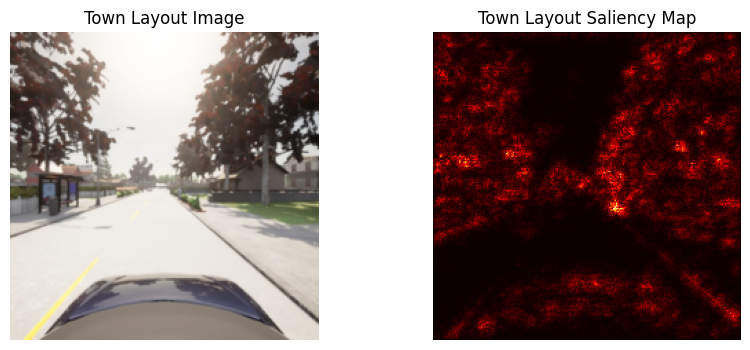

In [57]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image.permute(1,2,0))
plt.title("Town Layout Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(saliency.squeeze().cpu(), cmap="hot")
plt.title("Town Layout Saliency Map")
plt.axis("off")

plt.show()